In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba
from pathlib import Path
import numpy as np
import pandas as pd

from aind_hcr_data_loader.codeocean_utils import (
    MouseRecord,
    attach_mouse_record_to_workstation,
    print_attach_results,
)
from aind_hcr_data_loader.hcr_dataset import create_hcr_dataset_from_schema
from aind_hcr_data_loader.pairwise_dataset import create_pairwise_unmixing_dataset

import aind_hcr_qc.viz as viz
from aind_hcr_qc.viz.intergrated_datasets import plot_intensity_violins
from aind_hcr_qc.viz.single_cell_unmixing import (
    plot_spot_projection,
    plot_spot_measure_distributions,
    plot_cell_qc,
    plot_spot_nn_distances,
    plot_adjacent_channel_scatter,
    collect_nn_dists_all_cells,
    plot_nn_euclidean_dists,
    plot_nn_grid_pooled,
    plot_nn_euclidean_dists_pooled,
)

import aind_hcr_qc.viz.single_cell_unmixing as scu

from aind_hcr_qc.viz.spot_detection import (
    annotate_spots_df,
    plot_removal_metric_distributions,
)
from aind_hcr_qc.constants import Z1_CHANNEL_CMAP_VIBRANT


In [2]:
# notebook setup
data_dir = Path('/root/capsule/data')
bucket_name = "aind-open-data"

# notebook configuration
%matplotlib inline
%load_ext autoreload
%autoreload 2


In [ ]:
# ── configuration ────────────────────────────────────────────────────────────
MOUSE_ID = "767022"
  # use a mouse that has a pairwise_unmixing derived asset
CATALOG_PATH = Path(f"/src/ophys-mfish-dataset-catalog/mice/{MOUSE_ID}.json")
DATA_DIR     = Path("/root/capsule/data")
OUTPUT_DIR = Path(f"/root/capsule/scratch/single_cell_unmixing/{MOUSE_ID}")

# ── attach & load ────────────────────────────────────────────────────────────
record  = MouseRecord.from_json_file(CATALOG_PATH)
results = attach_mouse_record_to_workstation(record)
print_attach_results(results)

dataset = create_hcr_dataset_from_schema(CATALOG_PATH, DATA_DIR)
dataset.summary()

# ── pairwise unmixing (optional) ─────────────────────────────────────────────
# The pairwise asset name lives in derived_assets["pairwise_unmixing"] when present.
pairwise_asset_name = record.derived_assets.get("pairwise_unmixing")

if pairwise_asset_name is not None:
    pairwise_asset_path = DATA_DIR / pairwise_asset_name
    # Some pipeline outputs nest data under a "pairwise_unmixing" subfolder
    if (pairwise_asset_path / "pairwise_unmixing").exists():
        pairwise_asset_path = pairwise_asset_path / "pairwise_unmixing"
    pw_ds = create_pairwise_unmixing_dataset(
        mouse_id=MOUSE_ID,
        pairwise_asset_path=pairwise_asset_path,
        source_dataset=dataset,   # delegates zarr / segmentation calls
    )
    pw_ds.summary()
else:
    print("No pairwise_unmixing asset found in catalog record — skipping.")


  [rounds.R1]  HCR_767022_2025-07-03_13-00-00_processed_2025-07-18_09-27-44  →  ✓ attached
  [rounds.R2]  HCR_767022_2025-07-11_13-00-00_processed_2025-07-21_17-35-18  →  ✓ attached
  [rounds.R3]  HCR_767022_2025-07-18_13-00-00_processed_2025-07-21_17-35-38  →  ✓ attached
  [rounds.R4]  HCR_767022_2025-07-25_13-00-00_processed_2025-07-26_19-56-19  →  ✓ attached
  [rounds.R5]  HCR_767022_2025-07-31_13-00-00_processed_2025-08-01_16-55-47  →  ✓ attached
  [derived_assets.roi_shape_metrics]  HCR_767022_2025-07-03_13-00-00_roi-shape-metrics  →  ✓ attached
  [derived_assets.cell_typing]  HCR_767022_cell-typing_2026-03-08_12-00-00  →  ✓ attached
  [derived_assets.pairwise_unmixing]  HCR_767022_pairwise-unmixing_2026-04-15_21-20-26  →  ✓ attached
[DEBUG get_spot_files] key=R1 round_num=1
[DEBUG get_spot_files] folder_path=/root/capsule/data/HCR_767022_2025-07-03_13-00-00_processed_2025-07-18_09-27-44/image_spot_spectral_unmixing exists=False
[DEBUG get_spot_files] unmixed_spots=None  mixed_spo

/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:2500: UserWarning: [get_spot_files] R4: no unmixed_spots_R4*.pkl found; falling back to R-1 file: unmixed_spots_R-1_minDist_3.pkl
  _warnings.warn(
/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:2509: UserWarning: [get_spot_files] R4: no mixed_spots_R4.pkl found; falling back to R-1 file: mixed_spots_R-1.pkl
  _warnings.warn(


mouse_id: 767022
Could not load metadata for mouse 767022
Cell-typing asset attached: CellTypingFiles(asset='HCR_767022_cell-typing_2026-03-08_12-00-00', basic_results=✓, h5ad=✓)
HCR Dataset Summary
Mouse ID: 767022
Rounds: R1, R2, R3, R4, R5

Channels by round:
  R1: 405, 488, 514, 594
  R2: 594, 514, 488, 638, 405, 561
  R3: 488, 514, 594, 638, 405, 561
  R4: 561, 514, 405, 594, 638, 488
  R5: 594, 638, 514, 488, 561, 405

Cell-typing: ✓  (CellTypingFiles(asset='HCR_767022_cell-typing_2026-03-08_12-00-00', basic_results=✓, h5ad=✓))

Segmentation files by round:
  R1: resolutions 0, 2, centroids: ✓
  R2: resolutions 0, 2, centroids: ✗
  R3: resolutions 0, 2, centroids: ✗
  R4: resolutions 0, 2, centroids: ✗
  R5: resolutions 0, 2, centroids: ✗

Spot detection files by round:
  R2: channels 638, 488, 514, 561, 594
    638: spots ✓, stats files: 5
    488: spots ✓, stats files: 5
    514: spots ✓, stats files: 5
    561: spots ✓, stats files: 5
    594: spots ✓, stats files: 5
  R3: cha

In [4]:

# channel display order and fixed colors
CHAN_ORDER  = ["488", "514", "561", "594", "638"]
CHAN_COLORS = {k: v for k, v in Z1_CHANNEL_CMAP_VIBRANT.items() if k in CHAN_ORDER}

# ── load spots (both tables) for this cell ───────────────────────────────────
mixed_all   = pw_ds.load_all_rounds_spots_mp(table_type="mixed_spots",   remove_fg_bg_cols=True)
unmixed_all = pw_ds.load_all_rounds_spots_mp(table_type="unmixed_spots",  remove_fg_bg_cols=True)

Loading mixed_spots for round R2: 767022_R2
Loading mixed_spots for round R4: 767022_R4
Loading mixed_spots for round R3: 767022_R3

Loading mixed_spots for round R5: 767022_R5



Number of mixed_spots: 3.238e+07
Loading unmixed_spots for round R3: 767022_R3
Loading unmixed_spots for round R2: 767022_R2
Loading unmixed_spots for round R4: 767022_R4



Loading unmixed_spots for round R5: 767022_R5

Number of unmixed_spots: 2.298e+07


In [5]:
# ── Annotate once (valid_spot-aware) ──────────────────────────────────────────
mixed_ann, unmixed_ann = scu.annotate_spots_with_valid(mixed_all, unmixed_all)

In [6]:
# ── Run exemplar selection & plotting for every round ─────────────────────────

rounds = sorted(mixed_all["round"].unique())
round_summaries = {}    # round_key → summary DataFrame
#round_exemplars = {}    # round_key → (exemplar_ids, slot_assignments)

for rk in rounds:
    print(f"\n{'═' * 60}")
    print(f"  {rk}")
    print(f"{'═' * 60}")

    # 1. build summary
    summary = scu.build_round_cell_summary(mixed_all, unmixed_all, rk)
    round_summaries[rk] = summary

#     print(f"  Cells: {len(summary)}")
#     print(f"  Category counts:\n{summary['category'].value_counts().to_string()}")

#     # 2. select exemplars
#     ex_ids, slots, all_slots = select_round_exemplars(summary)
#     round_exemplars[rk] = (ex_ids, slots)

#     print(f"\n  Selected {len(ex_ids)} exemplars covering "
#           f"{len(all_slots) - len(all_slots - set().union(*slots.values()) if slots else all_slots)}"
#           f"/{len(all_slots)} slots")

#     # 3. print table
#     print_exemplar_table(summary, ex_ids, slots)

#     # 4. plot
#     plot_round_exemplar_overview(summary, ex_ids, slots, rk)


════════════════════════════════════════════════════════════
  R2
════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════
  R3
════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════
  R4
════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════
  R5
════════════════════════════════════════════════════════════


In [7]:
ADJACENT_PAIRS = [("488", "514"), ("514", "561"), ("561", "594"), ("594", "638")]

In [ ]:
# Slc cell
cid = 66265
rk = "R2"


In [ ]:
mx_rnd = mixed_ann[mixed_ann["round"] == rk]
um_rnd = unmixed_ann[unmixed_ann["round"] == rk]

m_cell = mx_rnd[mx_rnd["cell_id"] == cid]
u_cell = um_rnd[um_rnd["cell_id"] == cid]

save_kwargs = {"save": True,"output_dir": Path(f"/root/capsule/code/single_cell_unmixing_temp_plots/"),"filename":f"{MOUSE_ID}_{cid}","show": False}
fig = plot_cell_qc(
    m_cell, u_cell, cell_id=cid, round_key=rk,
    chan_order=CHAN_ORDER, chan_colors=CHAN_COLORS,
    dataset=dataset,
    spots_df=u_cell,
    scatter_pairs=ADJACENT_PAIRS + [("488", "594")],
    **save_kwargs
)


  ▸ Ch 594 retained signal — cell 66265  (19 survivors, 34.5% removal)


/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:464: UserWarning: Getting cell info from cell x gene file. Does not include all segmentation masks; but this is usually fine.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/zarr/core/metadata/v2.py:190: ZarrUserWarning: Found an empty list of filters in the array metadata document. This is contrary to the Zarr V2 specification, and will cause an error in the future. Use None (or Null in a JSON document) instead of an empty list of filters.
  warnings.warn(msg, ZarrUserWarning, stacklevel=1)
/opt/conda/lib/python3.12/site-packages/zarr/core/metadata/v2.py:190: ZarrUserWarning: Found an empty list of filters in the array metadata document. This is contrary to the Zarr V2 specification, and will cause an error in the future. Use None (or Null in a JSON document) instead of an empty list of filters.
  warnings.warn(msg, ZarrUserWarning, stacklevel=1)



1-NN cross-channel distance summary  ((x×y×z, pixels)):
     Direction      n    median      mean       std       min       max
     488 → 514     35     4.123     4.529     1.504     2.236     7.348
     514 → 488    586    12.021    13.173     6.669     2.236    42.837
     514 → 561    586    13.910    14.708     6.550     3.000    42.059
     561 → 514     19     4.243     4.599     1.171     3.000     7.483
     561 → 594     19     6.403     7.958     4.309     4.123    23.791
     594 → 561    149    13.565    14.590     6.172     4.123    31.193
     594 → 638    149    21.095    22.902     9.215     6.557    50.448
     638 → 594      7     8.602     8.952     1.367     6.557    11.180

   Ch       n   med_ratio   med_z_int   med_score   % score>1
  488      35      13.665        1.11      14.029       94.3%
  514     586       0.029        6.02       0.029        0.0%
  561      19       1.757       -0.20       1.791       63.2%
  594     149      56.595       -0.75      99.

# Cluster Cells

In [9]:
labels = pd.read_csv("/root/capsule/data/HCR_767022_pairwise-unmixing_2026-04-15_21-20-26/pairwise_unmixing/inhibitory_cells_unmixed/unmixed_cluster_labels.csv")
cell_ids = pd.read_csv("/root/capsule/data/HCR_767022_pairwise-unmixing_2026-04-15_21-20-26/pairwise_unmixing/inhibitory_cells_unmixed/unmixed_sorted_cell_ids.csv")

In [10]:
# merge labels and cell_ids on index
labels["cell_id"] = cell_ids["cell_id"]
# sample 1 cell from each cluster
cluster_exemplars = labels.groupby("cluster").sample(n=1, random_state=42)
cluster_exemplars

,Unnamed: 0,cluster,cell_id
68,68,0,18713
268,268,1,19563
372,372,2,65694
455,455,3,10784
623,623,4,26965
775,775,5,8593
987,987,6,61808
1167,1167,7,60555
1419,1419,8,63812
1586,1586,9,41984


In [11]:
# get all cells from cluster
cluster = 7
cluster_cells = labels[labels["cluster"] == cluster]["cell_id"].tolist()
rk = "R2"


mx_rnd = mixed_ann[mixed_ann["round"] == rk]
um_rnd = unmixed_ann[unmixed_ann["round"] == rk]
m_cluster_spots = mx_rnd[mx_rnd["cell_id"].isin(cluster_cells)]
u_cluster_spots = um_rnd[um_rnd["cell_id"].isin(cluster_cells)]

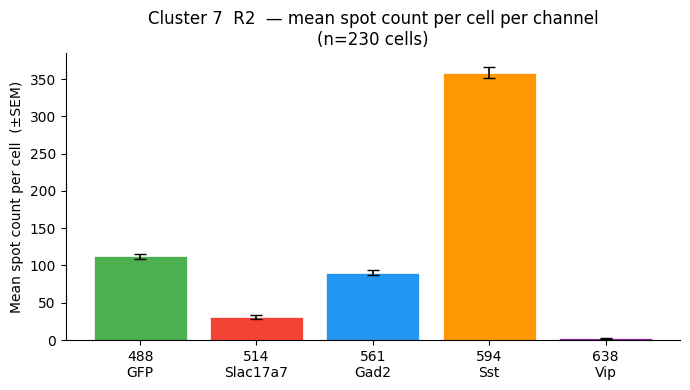

In [13]:
# mean spot count per cell per channel, colored by channel, gene on x-axis
spot_counts = (
    u_cluster_spots.groupby(["cell_id", "chan"])
    .size()
    .reset_index(name="n_spots")
)
mean_counts = spot_counts.groupby("chan")["n_spots"].mean()
sem_counts  = spot_counts.groupby("chan")["n_spots"].sem()

# one gene per channel per round — take first occurrence
chan_to_gene = (
    u_cluster_spots.groupby("chan")["mixed_gene"]
    .first()
    .reindex(CHAN_ORDER)
)

chans = [c for c in CHAN_ORDER if c in mean_counts.index]
x = np.arange(len(chans))

fig, ax = plt.subplots(figsize=(len(chans) * 1.4, 4))
for i, chan in enumerate(chans):
    gene = chan_to_gene.get(chan, "")
    ax.bar(i, mean_counts[chan], yerr=sem_counts[chan],
           color=CHAN_COLORS.get(chan, "grey"),
           edgecolor="white", linewidth=0.5,
           capsize=4, error_kw={"elinewidth": 1.2})

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{c}\n{chan_to_gene.get(c, '')}" for c in chans],
    fontsize=10
)
ax.set_ylabel("Mean spot count per cell  (±SEM)")
ax.set_title(
    f"Cluster {cluster}  {rk}  — mean spot count per cell per channel\n"
    f"(n={len(cluster_cells)} cells)"
)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()


## plot 1 cell cluster

In [ ]:
cluster = 7

ch ='594'
cid = cluster_exemplars[cluster_exemplars["cluster"] == cluster]["cell_id"].iloc[0]
rk = "R2"


mx_rnd = mixed_ann[mixed_ann["round"] == rk]
um_rnd = unmixed_ann[unmixed_ann["round"] == rk]

m_cell = mx_rnd[mx_rnd["cell_id"] == cid]
u_cell = um_rnd[um_rnd["cell_id"] == cid]

save_kwargs = {"save": True,"output_dir": Path(f"/root/capsule/code/single_cell_unmixing_temp_plots/"),"filename":f"{MOUSE_ID}_{cid}","show": False}
fig = plot_cell_qc(
    m_cell, u_cell, cell_id=cid, round_key=rk,
    chan_order=CHAN_ORDER, chan_colors=CHAN_COLORS,
    dataset=dataset,
    spots_df=u_cell,
    scatter_pairs=ADJACENT_PAIRS + [("488", "594")],
    **save_kwargs
)

IndexError: single positional indexer is out-of-bounds

# NN single cell

In [ ]:
NN_CHANNELS = ADJACENT_PAIRS + [("488", "594")]

/tmp/ipykernel_9392/3087734001.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7, framealpha=0.4)


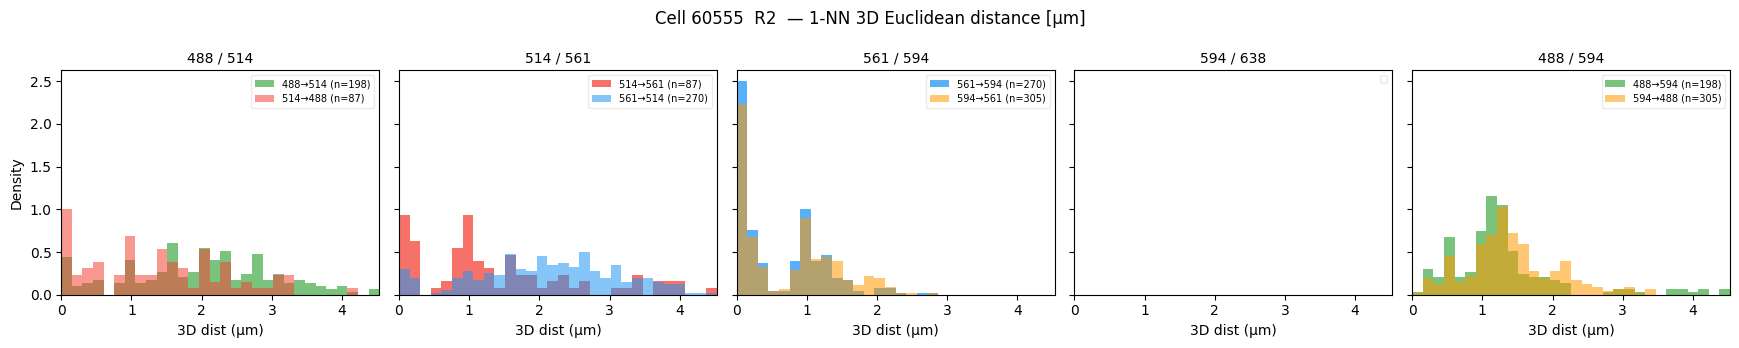

In [ ]:
plot_nn_euclidean_dists(m_cell, NN_CHANNELS, CHAN_COLORS, cid, rk, voxel_size=VOXEL_SIZE)


/tmp/ipykernel_9392/1490876093.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_xy.legend(fontsize=7, framealpha=0.4)
/tmp/ipykernel_9392/1490876093.py:76: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_z.legend(fontsize=7, framealpha=0.4)


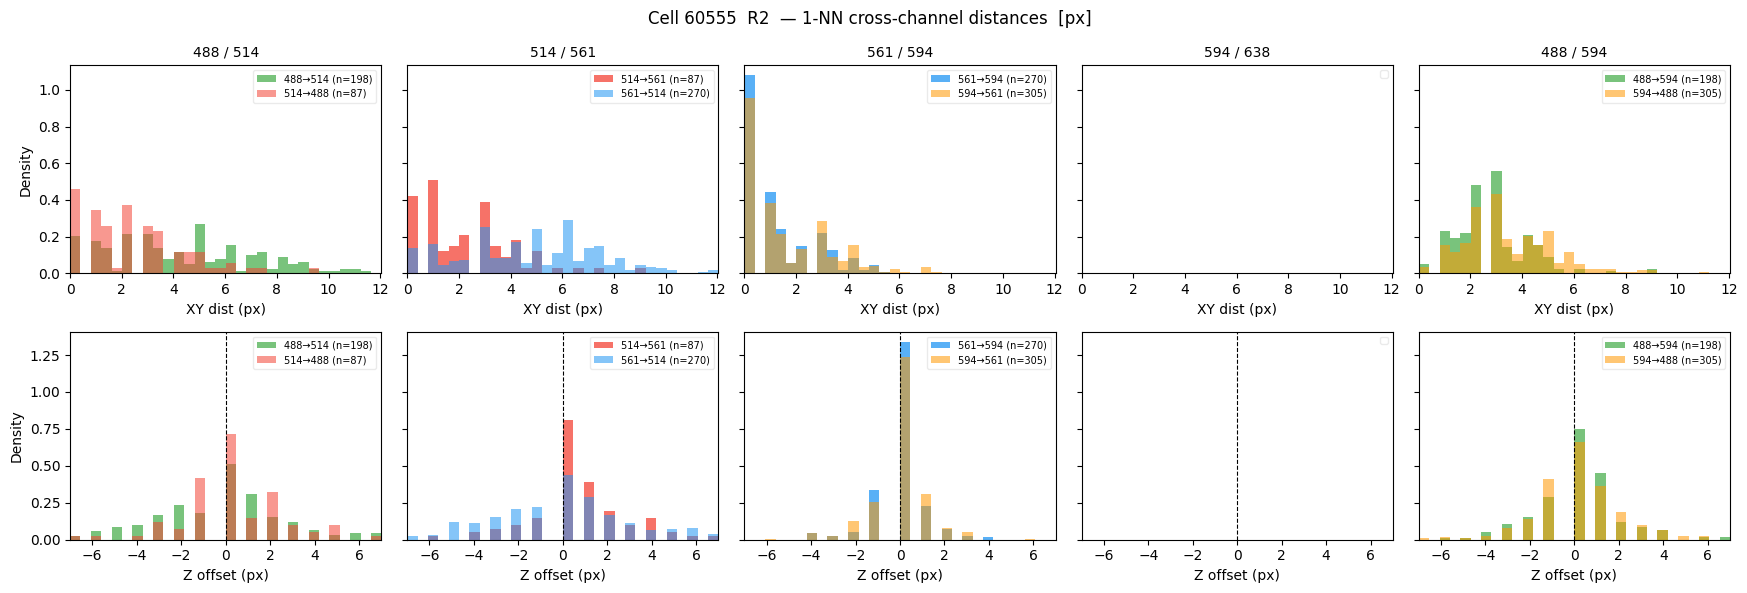

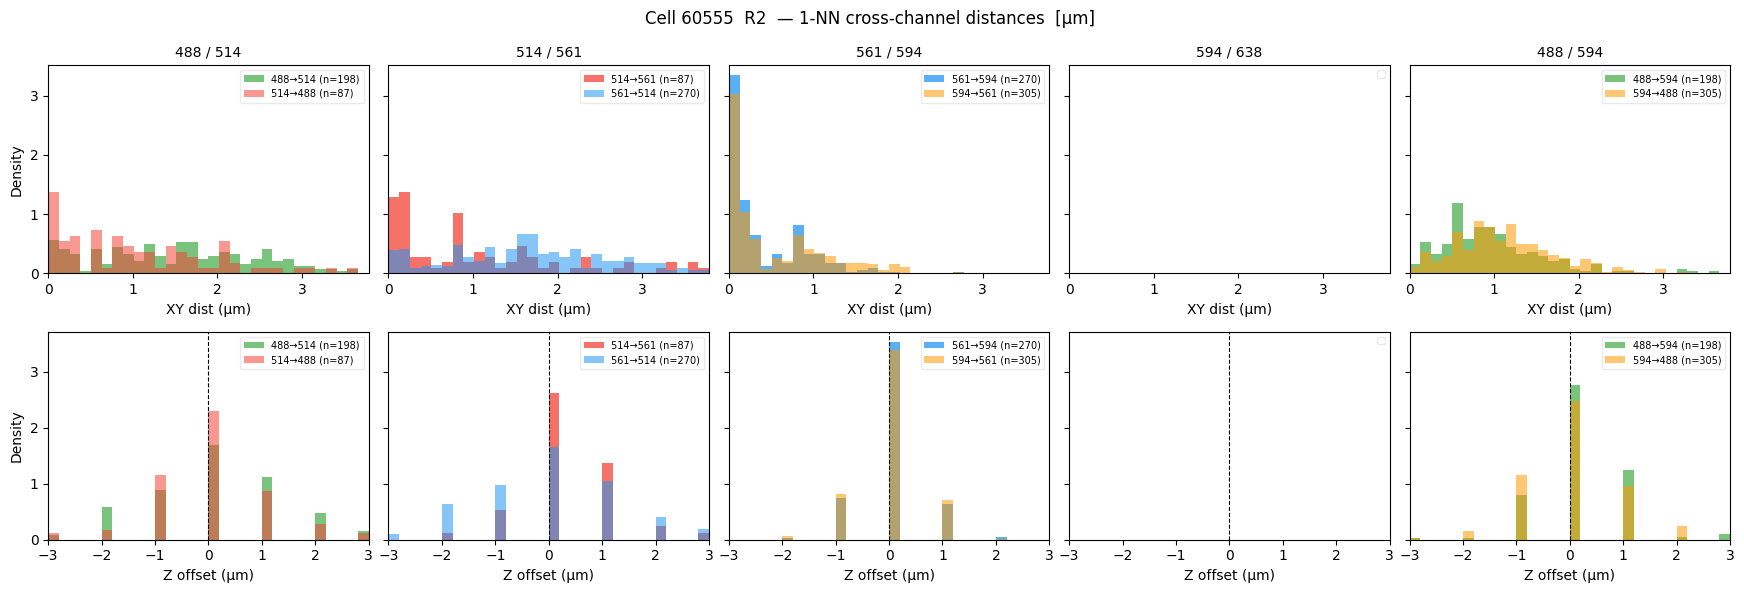

In [ ]:
VOXEL_SIZE = {"z": 1.0, "y": 0.24, "x": 0.24}  # µm/px

# ── pixels ────────────────────────────────────────────────────────────────────
scu._plot_nn_grid(m_cell, NN_CHANNELS, CHAN_COLORS, cid, rk, voxel_size=None)

# ── microns  (z=1, y=x=0.24 µm/px) ──────────────────────────────────────────
scu._plot_nn_grid(m_cell, NN_CHANNELS, CHAN_COLORS, cid, rk, voxel_size=VOXEL_SIZE)


# NN pooled cells

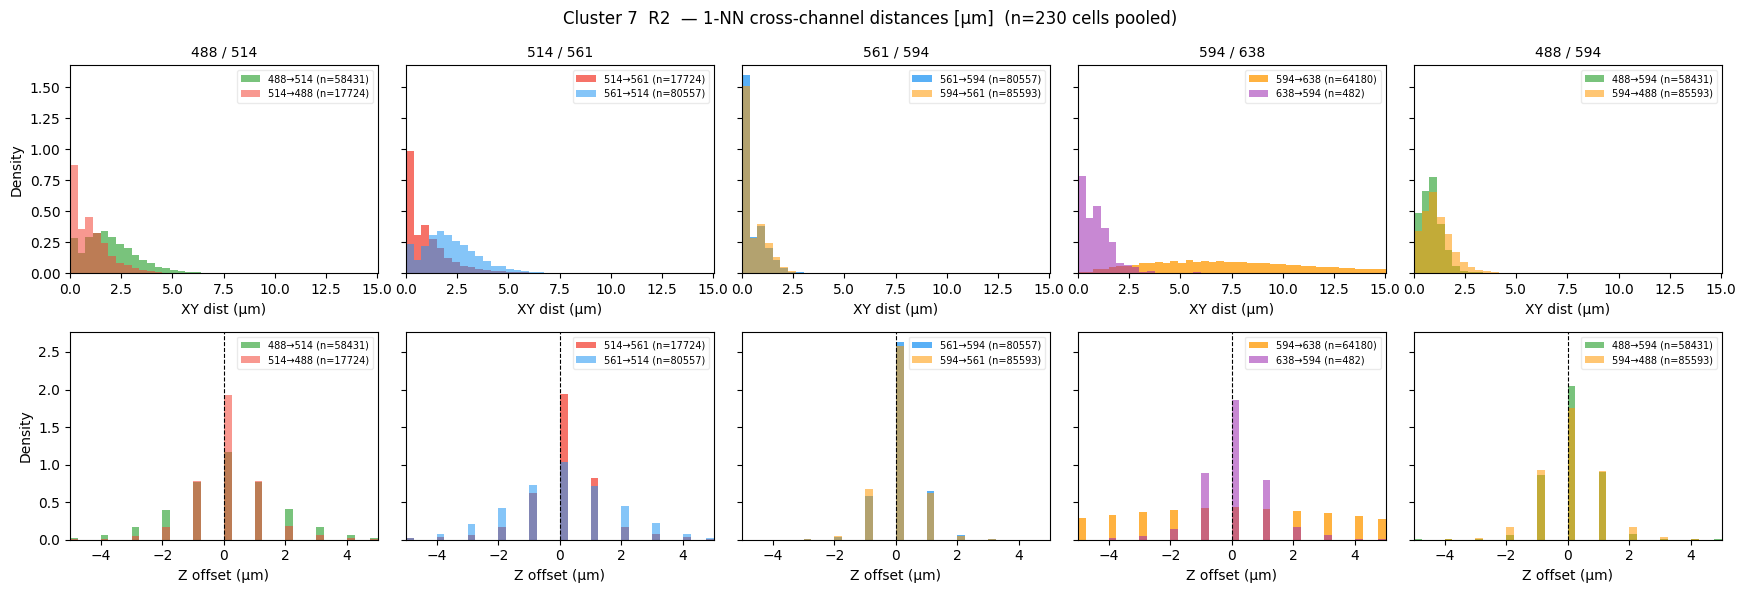

In [ ]:
plot_nn_grid_pooled(m_cluster_spots, NN_CHANNELS, CHAN_COLORS,
                    label=f"Cluster {cluster}  {rk}",
                    voxel_size=VOXEL_SIZE)


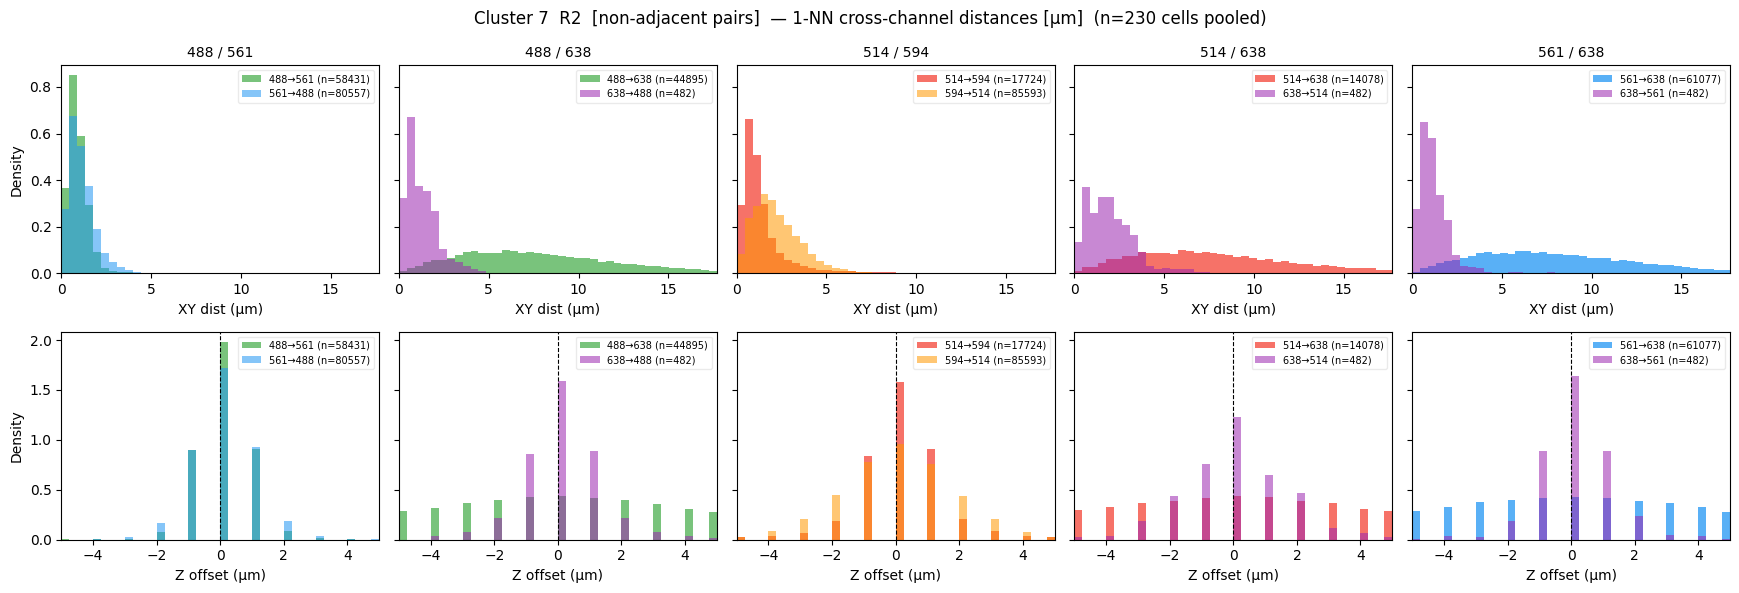

In [ ]:
OTHER_PAIRS = [
    (a, b)
    for i, a in enumerate(CHAN_ORDER)
    for b in CHAN_ORDER[i+1:]
    if (a, b) not in NN_CHANNELS
]

plot_nn_grid_pooled(m_cluster_spots, OTHER_PAIRS, CHAN_COLORS,
                    label=f"Cluster {cluster}  {rk}  [non-adjacent pairs]",
                    voxel_size=VOXEL_SIZE)


# NN pooled cells (um)

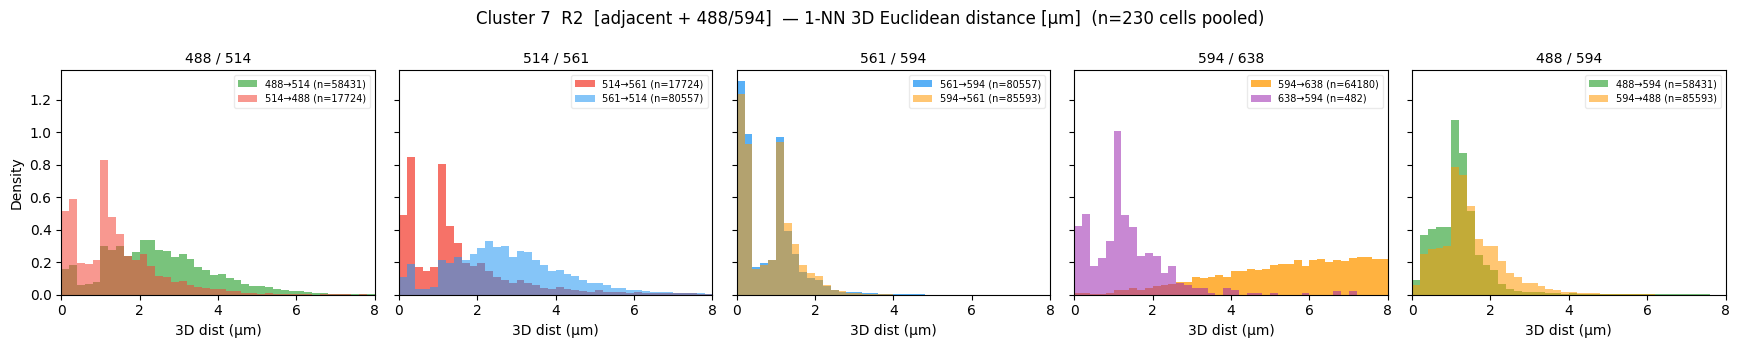

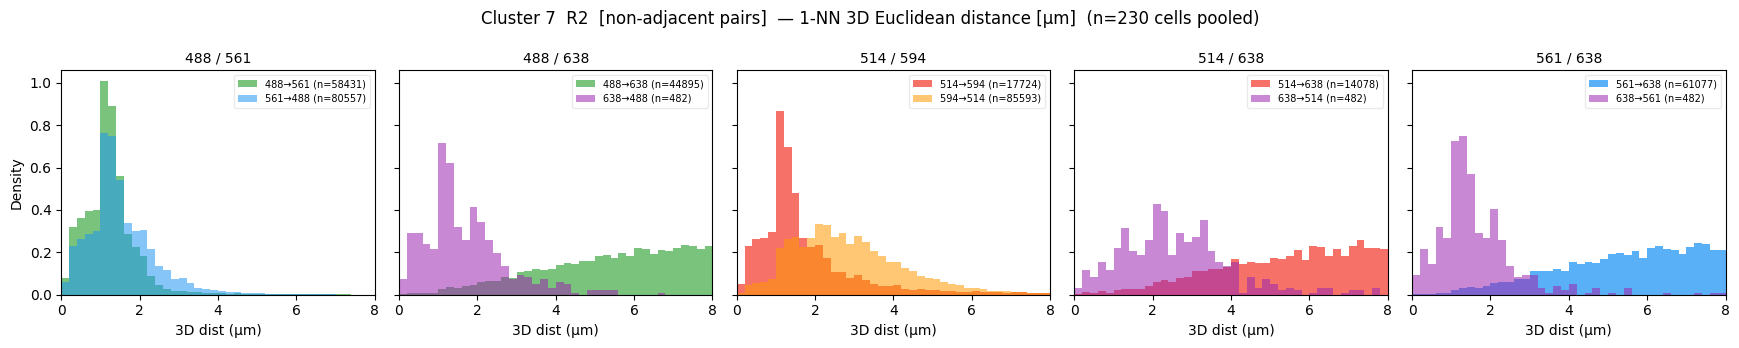

In [ ]:
plot_nn_euclidean_dists_pooled(m_cluster_spots, NN_CHANNELS, CHAN_COLORS,
                               label=f"Cluster {cluster}  {rk}  [adjacent + 488/594]",
                               voxel_size=VOXEL_SIZE)

plot_nn_euclidean_dists_pooled(m_cluster_spots, OTHER_PAIRS, CHAN_COLORS,
                               label=f"Cluster {cluster}  {rk}  [non-adjacent pairs]",
                               voxel_size=VOXEL_SIZE)


# More Examples

In [ ]:
ch ='594'
cid = 1629
rk = "R2"


mx_rnd = mixed_ann[mixed_ann["round"] == rk]
um_rnd = unmixed_ann[unmixed_ann["round"] == rk]

row = summary[summary["cell_id"] == cid].iloc[0]
n_surv = int(row.get(f"n_unmixed_{ch}", 0))
rr = row.get(f"removal_rate_{ch}", 0)
print(f"\n  ▸ Ch {ch} retained signal — cell {cid}  "
        f"({n_surv} survivors, {rr:.1%} removal)")

m_cell = mx_rnd[mx_rnd["cell_id"] == cid]
u_cell = um_rnd[um_rnd["cell_id"] == cid]

plot_cell_qc(
    m_cell, u_cell, cell_id=cid, round_key=rk,
    chan_order=CHAN_ORDER, chan_colors=CHAN_COLORS,
    dataset=dataset,
    spots_df=u_cell,
    scatter_pairs=ADJACENT_PAIRS + [("488", "594")]
)
plt.show()

In [ ]:
plot_cell_qc( _mx, _um, cell_id=_test_cid, round_key=_test_rk, chan_order=CHAN_ORDER, spots_df=_um,chan_colors=CHAN_COLORS, dataset=dataset, scatter_pairs=ADJACENT_PAIRS + [("488", "561")])


In [14]:
# ── Run focused exemplar selection & detail plots per round ───────────────────

focused_exemplars = {}  # round_key → (retained, pair_loss)

for rk in rounds:  # just do the last round for brevity
    summary = round_summaries[rk]
    retained, pair_loss = scu.select_focused_exemplars(summary)
    focused_exemplars[rk] = (retained, pair_loss)

    print(f"\n{'═' * 70}")
    print(f"  {rk}")
    print(f"{'═' * 70}")

    # # ── filter round data ────────────────────────────────────────────────────
    # mx_rnd = mixed_ann[mixed_ann["round"] == rk]
    # um_rnd = unmixed_ann[unmixed_ann["round"] == rk]

    # # ── retained signal exemplars ────────────────────────────────────────────
    # for ch, cid in retained.items():
    #     row = summary[summary["cell_id"] == cid].iloc[0]
    #     n_surv = int(row.get(f"n_unmixed_{ch}", 0))
    #     rr = row.get(f"removal_rate_{ch}", 0)
    #     print(f"\n  ▸ Ch {ch} retained signal — cell {cid}  "
    #           f"({n_surv} survivors, {rr:.1%} removal)")

    #     m_cell = mx_rnd[mx_rnd["cell_id"] == cid]
    #     u_cell = um_rnd[um_rnd["cell_id"] == cid]

    #     plot_cell_qc(
    #         m_cell, u_cell, cell_id=cid, round_key=rk,
    #         chan_order=CHAN_ORDER, chan_colors=CHAN_COLORS,
    #     )
    #     plt.show()

    # # ── pair loss exemplars ──────────────────────────────────────────────────
    # for (a, b), cid in pair_loss.items():
    #     row = summary[summary["cell_id"] == cid].iloc[0]
    #     ra = row.get(f"removal_rate_{a}", 0)
    #     rb = row.get(f"removal_rate_{b}", 0)
    #     print(f"\n  ▸ Pair {a}↔{b} loss — cell {cid}  "
    #           f"(removal {a}: {ra:.1%}, {b}: {rb:.1%})")

    #     m_cell = mx_rnd[mx_rnd["cell_id"] == cid]
    #     u_cell = um_rnd[um_rnd["cell_id"] == cid]

    #     # spot projection + quality measures
    #     plot_cell_qc(
    #         m_cell, u_cell, cell_id=cid, round_key=rk,
    #         chan_order=CHAN_ORDER, chan_colors=CHAN_COLORS,
    #     )
    #     plt.show()

    #     # adjacent channel scatter focused on this pair
    #     plot_adjacent_channel_scatter(
    #         m_cell, u_cell, cell_id=cid, round_key=rk,
    #         chan_order=CHAN_ORDER, chan_colors=CHAN_COLORS,
    #         pairs=[(a, b)],
    #     )
    #     plt.show()


══════════════════════════════════════════════════════════════════════
  R2
══════════════════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════════════════
  R3
══════════════════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════════════════
  R4
══════════════════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════════════════
  R5
══════════════════════════════════════════════════════════════════════
